In [ ]:
!pip install ultralytics roboflow


In [ ]:
!pip install inference_sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.6 MB/s eta 0:00:00


In [ ]:
from inference_sdk import InferenceHTTPClient

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key="HC8JG3C3HInUJGOU5MVd"
)


result = CLIENT.infer('https://source.roboflow.com/9FJDGFlsxzSm6ol0IO4wKuAj6Lz1/011L1ugk1UE40GaqDOwC/original.jpg', model_id="ppe-detection-qlq3d/1")
print(result)

{'inference_id': 'f3473123-1439-4ad2-9883-a5071a9deb1d', 'time': 0.22599104500022804, 'image': {'width': 483, 'height': 450}, 'predictions': [{'x': 308.0, 'y': 350.0, 'width': 348.0, 'height': 198.0, 'confidence': 0.8348917961120605, 'class': 'vest', 'class_id': 9, 'detection_id': 'a41d19c7-d048-4707-b77d-bd6099e0c2be'}, {'x': 213.0, 'y': 63.0, 'width': 248.0, 'height': 126.0, 'confidence': 0.8240549564361572, 'class': 'helmet', 'class_id': 3, 'detection_id': 'ad1885eb-3fc7-4256-8d9d-2cb7aad263b0'}, {'x': 204.0, 'y': 132.5, 'width': 208.0, 'height': 93.0, 'confidence': 0.7140263319015503, 'class': 'goggles', 'class_id': 2, 'detection_id': '6cc52a8e-b48e-4366-b3b6-11611f0fae47'}]}


In [ ]:
!pip install roboflow supervision opencv-python

loading Roboflow workspace...
loading Roboflow project...


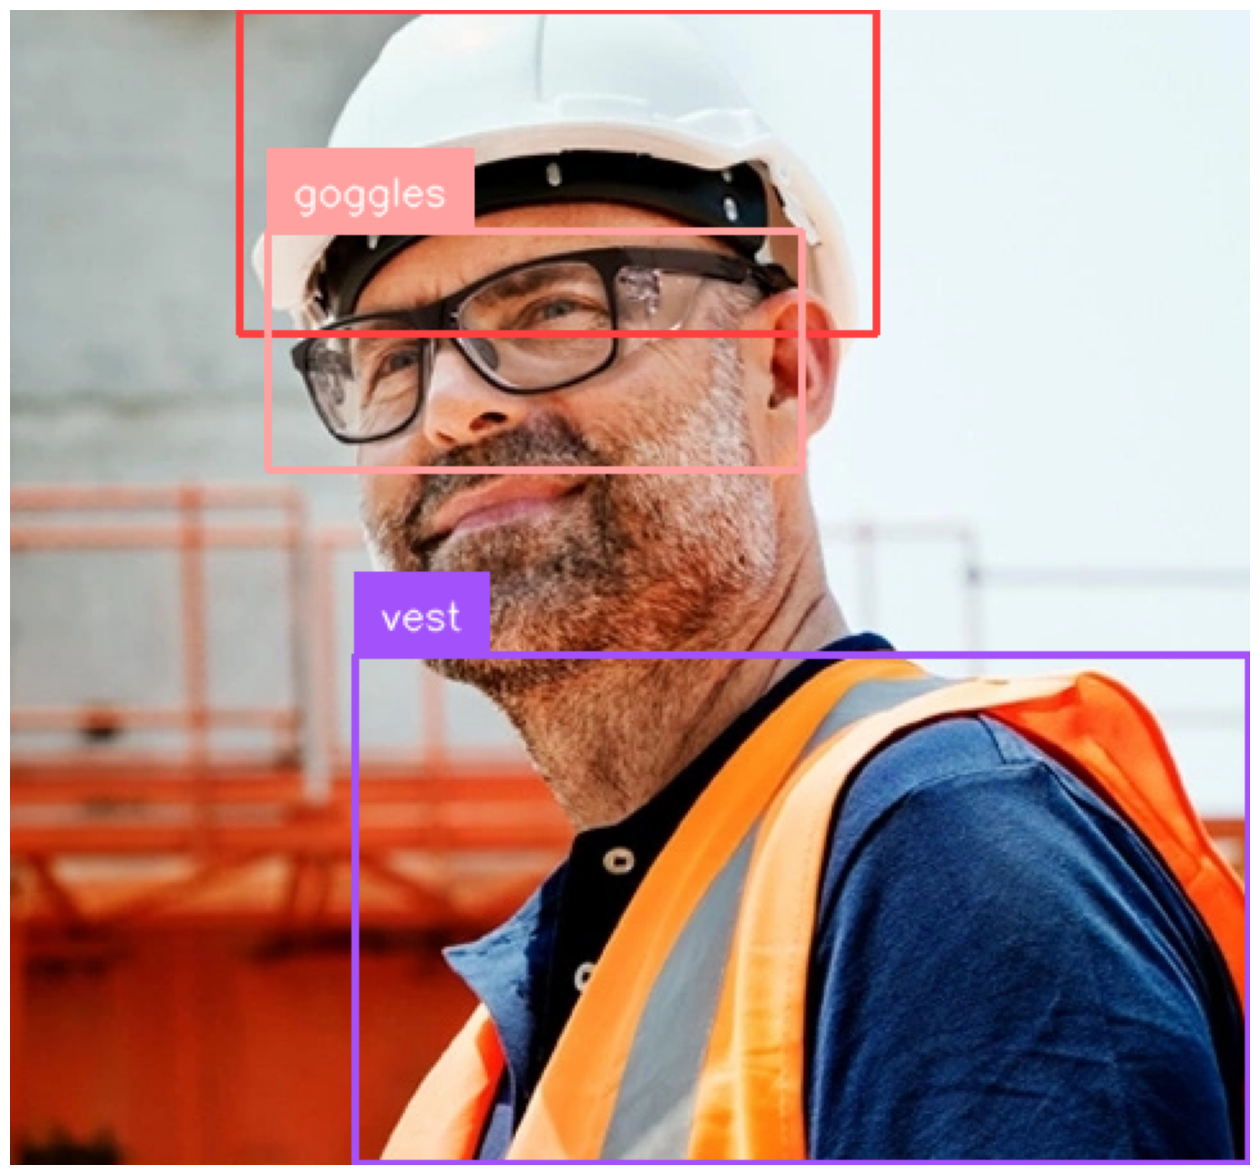

In [ ]:
import numpy as np
from roboflow import Roboflow
import supervision as sv
import cv2

# Initialize Roboflow API
rf = Roboflow(api_key="HC8JG3C3HInUJGOU5MVd")
project = rf.workspace().project("ppe-detection-qlq3d")
model = project.version(1).model

# Make a prediction
result = model.predict("/content/original.jpg", confidence=40, overlap=30).json()

# Manually create a list of detections from Roboflow predictions
boxes = []
labels = []
for item in result['predictions']:
    x, y, width, height = item['x'], item['y'], item['width'], item['height']
    # Convert Roboflow format (center_x, center_y, width, height) to supervision format (x1, y1, x2, y2)
    x1 = x - width / 2
    y1 = y - height / 2
    x2 = x + width / 2
    y2 = y + height / 2
    boxes.append([x1, y1, x2, y2])
    labels.append(item['class'])

# Ensure boxes are a NumPy array with shape (_, 4)
boxes = np.array(boxes)

# Create a Detections object from supervision using the parsed boxes
detections = sv.Detections(
    xyxy=boxes,
    confidence=np.ones(len(boxes)),  # Dummy confidence values if needed
    class_id=np.arange(len(labels))  # Generate class IDs for labels
)

# Load the image
image = cv2.imread("/content/original.jpg")

# Annotators
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# Annotate the image with bounding boxes and labels
annotated_image = box_annotator.annotate(
    scene=image, detections=detections
)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections, labels=labels
)

# Show the annotated image
sv.plot_image(image=annotated_image, size=(16, 16))


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8x.yaml')
model = YOLO('yolov8x.pt')
model = YOLO('yolov8x.yaml').load('yolov8x.pt')



100%|██████████| 131M/131M [00:00<00:00, 240MB/s]


Transferred 595/595 items from pretrained weights


In [ ]:
!unzip -q /content/PPE-detection-1/roboflow.zip


unzip:  cannot find or open /content/PPE-detection-1/roboflow.zip, /content/PPE-detection-1/roboflow.zip.zip or /content/PPE-detection-1/roboflow.zip.ZIP.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="HC8JG3C3HInUJGOU5MVd")
project = rf.workspace("testcasque").project("ppe-detection-qlq3d")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-detection-1 in yolov8:: 100%|██████████| 10292/10292 [00:01<00:00, 5584.73it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from roboflow import Roboflow

# Initialize the Roboflow API
rf = Roboflow(api_key="HC8JG3C3HInUJGOU5MVd")  # Replace with your API key
project = rf.workspace().project("ppe-detection-qlq3d")
dataset = project.version(1).download("yolov8")  # Ensure 'yolov8' format


loading Roboflow workspace...
loading Roboflow project...


BadZipFile: File is not a zip file

In [ ]:
!curl -L "https://universe.roboflow.com/ds/MhEl858zed?key=YO4PwPAe4n" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   903  100   903    0     0   2230      0 --:--:-- --:--:-- --:--:--  2229
100  137M  100  137M    0     0  12.1M      0  0:00:11  0:00:11 --:--:-- 17.3M
Archive:  roboflow.zip
 extracting: README.dataset.txt      
 extracting: README.roboflow.txt     
 extracting: data.yaml               
   creating: test/
   creating: test/images/
 extracting: test/images/1-108-_jpg.rf.63d8899d5f864411eb8ba4094d4d70f0.jpg  
 extracting: test/images/1_0_0_20161219190621290-jpg-chip_jpg.rf.7df652ab335a0b4359c9141a939b5005.jpg  
 extracting: test/images/1_0_0_20161219190824794-jpg-chip_jpg.rf.4dd66c67109cff5810ffa5aa4cd46b34.jpg  
 extracting: test/images/1_0_0_20161219190824794-jpg-chip_jpg.rf.d0593cb5881b2d9d068563877b609239.jpg  
 extracting: test/images/1_0_0_20161219192713491-jpg-chip_jpg.rf.dc6482db4c183b017c69824a865a5f38.jpg  
 extract

In [ ]:
!pip install roboflow ultralytics

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 model (you can choose 'yolov8n', 'yolov8s', etc.)
model = YOLO("yolov8n.pt")  # You can change this to 'yolov8m.pt' or 'yolov8l.pt'

# Train the model on the dataset
model.train(
    data=f"/content/data.yaml",  # Path to the dataset's data.yaml file
    epochs=50,   # Number of training epochs
    imgsz=640,    # Image size (you can adjust this)
    batch=16,     # Batch size (adjust based on your GPU capabilities)
    device=0      # Use GPU (0) if available, otherwise CPU
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 341MB/s]

Ultralytics 8.3.29 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)


engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=False, int8=False, dynamic=

100%|██████████| 755k/755k [00:00<00:00, 99.5MB/s]


...

      50/50      2.28G     0.4177      1.007      1.116          5        640: 100%|██████████| 109/109 [00:33<00:00,  3.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:04<00:00,  3.94it/s]


                   all        496        497      0.694      0.697      0.761      0.661

50 epochs completed in 0.560 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.3MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.29 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,011,108 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:06<00:00,  2.46it/s]


                   all        496        497      0.694        0.7      0.761      0.661
         Female Age- 1          3          3          1      0.587      0.764      0.569
         Female Age- 2          2          2          1          0       0.17      0.146
        Female Age- 22         17         17      0.777      0.765      0.838        0.7
        Female Age- 24         28         28      0.682      0.843      0.876      0.768
        Female Age- 25         29         29       0.69      0.345      0.617      0.537
        Female Age- 28         33         34      0.729      0.789       0.78      0.672
        Female Age- 30         20         20      0.564       0.65      0.653      0.568
        Female Age- 35         13         13      0.613      0.692      0.693       0.62
        Female Age- 45         27         27      0.666      0.778      0.808      0.728
        Female Age- 50         15         15      0.646      0.667      0.774      0.695
        Female Age- 6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d8ccc278700>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,   

In [ ]:
!zip -r /content/model50epochv8n.zip /content/runs/detect/train

  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/labels_correlogram.jpg (deflated 37%)
  adding: content/runs/detect/train/R_curve.png (deflated 9%)
  adding: content/runs/detect/train/val_batch1_labels.jpg (deflated 6%)
  adding: content/runs/detect/train/train_batch0.jpg (deflated 1%)
  adding: content/runs/detect/train/train_batch4362.jpg (deflated 7%)
  adding: content/runs/detect/train/val_batch0_pred.jpg (deflated 7%)
  adding: content/runs/detect/train/results.csv (deflated 61%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 20%)
  adding: content/runs/detect/train/train_batch4361.jpg (deflated 5%)
  adding: content/runs/detect/train/train_batch4360.jpg (deflated 5%)
  adding: content/runs/detect/train/val_batch0_labels.jpg (deflated 7%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 2%)
  adding: content/runs/detect/train/val_batch2_labels.jpg (deflated 7%)
  adding: content/runs/detect/train/confusion_matr

In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding